## Preliminaries

As before, we need to start by:

1. Loading the Pandas and Statsmodels libraries

2. Reading the data from a CSV file

3. Fixing the column names using Panda’s rename() method


In [9]:
cd Downloads

[WinError 2] The system cannot find the file specified: 'Downloads'
C:\Users\abuel\Downloads


C:\Users\abuel\anaconda3\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [10]:
import pandas as pd
import statsmodels.api as sm

con = pd.read_csv('ConcreteStrength.csv')
con.rename(columns={'Fly ash': 'FlyAsh', 'Coarse Aggr.': "CoarseAgg",
                    'Fine Aggr.': 'FineAgg', 
                    'Compressive Strength (28-day)(Mpa)': 'Strength'}, inplace=True)
con.head(3)

,No,Cement,Slag,FlyAsh,Water,SP,CoarseAgg,FineAgg,Strength
0,1,273.0,82.0,105.0,210.0,9.0,904.0,680.0,34.990
1,2,163.0,149.0,191.0,180.0,12.0,843.0,746.0,32.272
2,3,162.0,148.0,191.0,179.0,16.0,840.0,743.0,35.450


I then define to separate data frames:

Y to hold my response variable (the single column “Strength”)

X to hold my explanatory variables

I complete my X matrix by running the Statsmodels add_constant() method, as explained in the tutorial on linear regression.

In [11]:
Y = con['Strength']
X = con[['No',
 'Cement',
 'Slag',
 'FlyAsh',
 'Water',
 'SP',
 'CoarseAgg',
 'FineAgg']]
X = sm.add_constant(X)

## Start with the OLS model

In [12]:
ks = sm.OLS(Y, X)
ks_res =ks.fit()
ks_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Strength   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     56.21
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.68e-32
Time:                        12:46:20   Log-Likelihood:                -284.49
No. Observations:                 103   AIC:                             587.0
Df Residuals:                      94   BIC:                             610.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        115.2834    142.786      0.807      0.421    -168.222     398.789
No            -0.0077      0.021     -0.372      0.711      -0.049       0.033
Cement         0.0826      0.047      1.758      0.082      -0.011       0.176
Slag          -0.0225      0.065     -0.346      0.730      -0.152       0.107
FlyAsh         0.0668      0.048      1.380      0.171      -0.029       0.163
Water         -0.2165      0.142     -1.520      0.132      -0.499       0.066
SP             0.2518      0.213      1.181      0.241      -0.172       0.675
CoarseAgg     -0.0479      0.056     -0.857      0.393      -0.159       0.063
FineAgg       -0.0356      0.057     -0.622      0.536      -0.149       0.078
==============================================================================
Omnibus:                        2.168   Durbin-Watson:                   1.715
Prob(Omnibus):                  0.338   Jarque-Bera (JB):                2.183
Skew:                          -0.309   Prob(JB):                        0.336
Kurtosis:                       2.644   Cond. No.                     4.36e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.36e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Checking for Colinearity

## Start with Scatterplot Matrix

We can run a scatterplot matrix on our original X matrix using Seaborn’s handy pairplot() method. A nice feature of this presentation is a histogram for each variable. Note that this may take a few seconds to generate so you have to be patient.

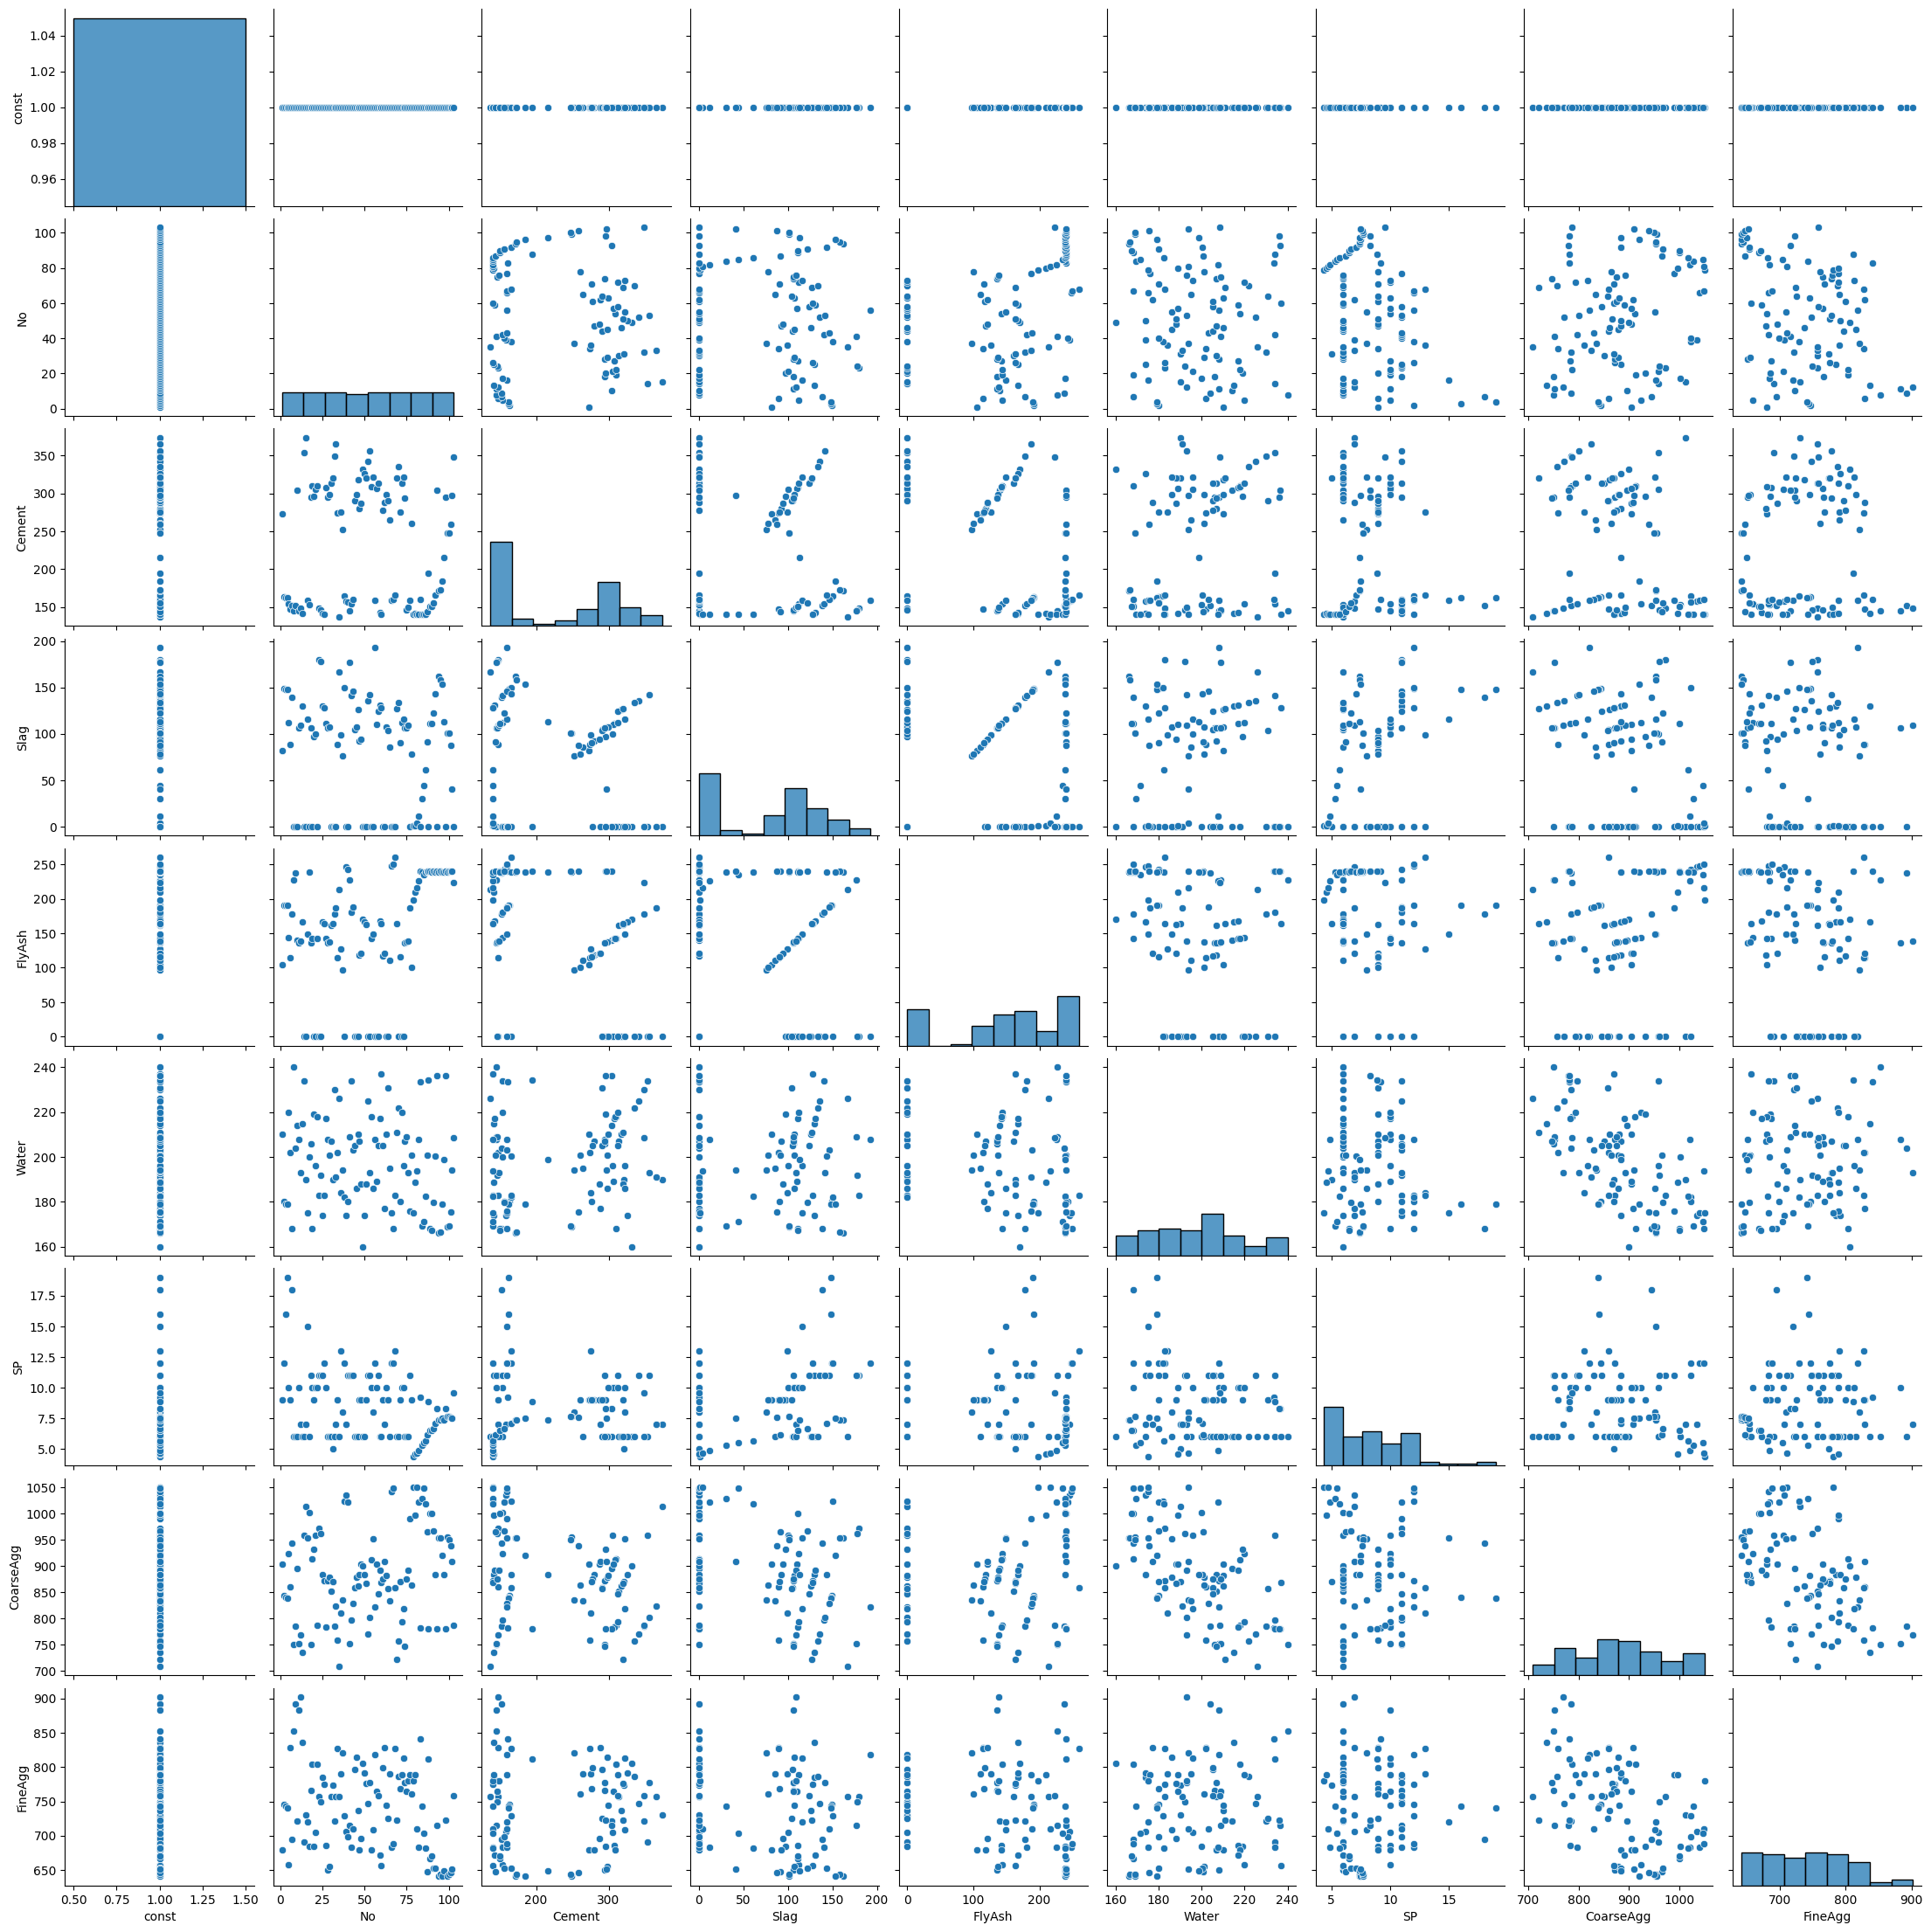

In [13]:
import seaborn as sns
sns.pairplot(X);

## Restricting variables in the scatterplot matrix
With wide data sets (many columns), the scatterplots become unreadable. Thus, it is often better to restrict the variables in the scatterplot matrix to a named set in order to maximize readability. Here I have excluded the constant, response variable, and all dummy columns.

A few things that catch my eye in the scatterplot matrix:

The “No” variable (experiment number) does not appear to be correlated with any other variable. That is good news—we should not expect it to in a well-run experiment.

There is some linearity and other weirdness in the relationships between “FlyAsh”, “Slag”, and “Cement”. This suggests problems with the experimental design. Unfortunately, these problems cannot be fixed in the data analysis stage.

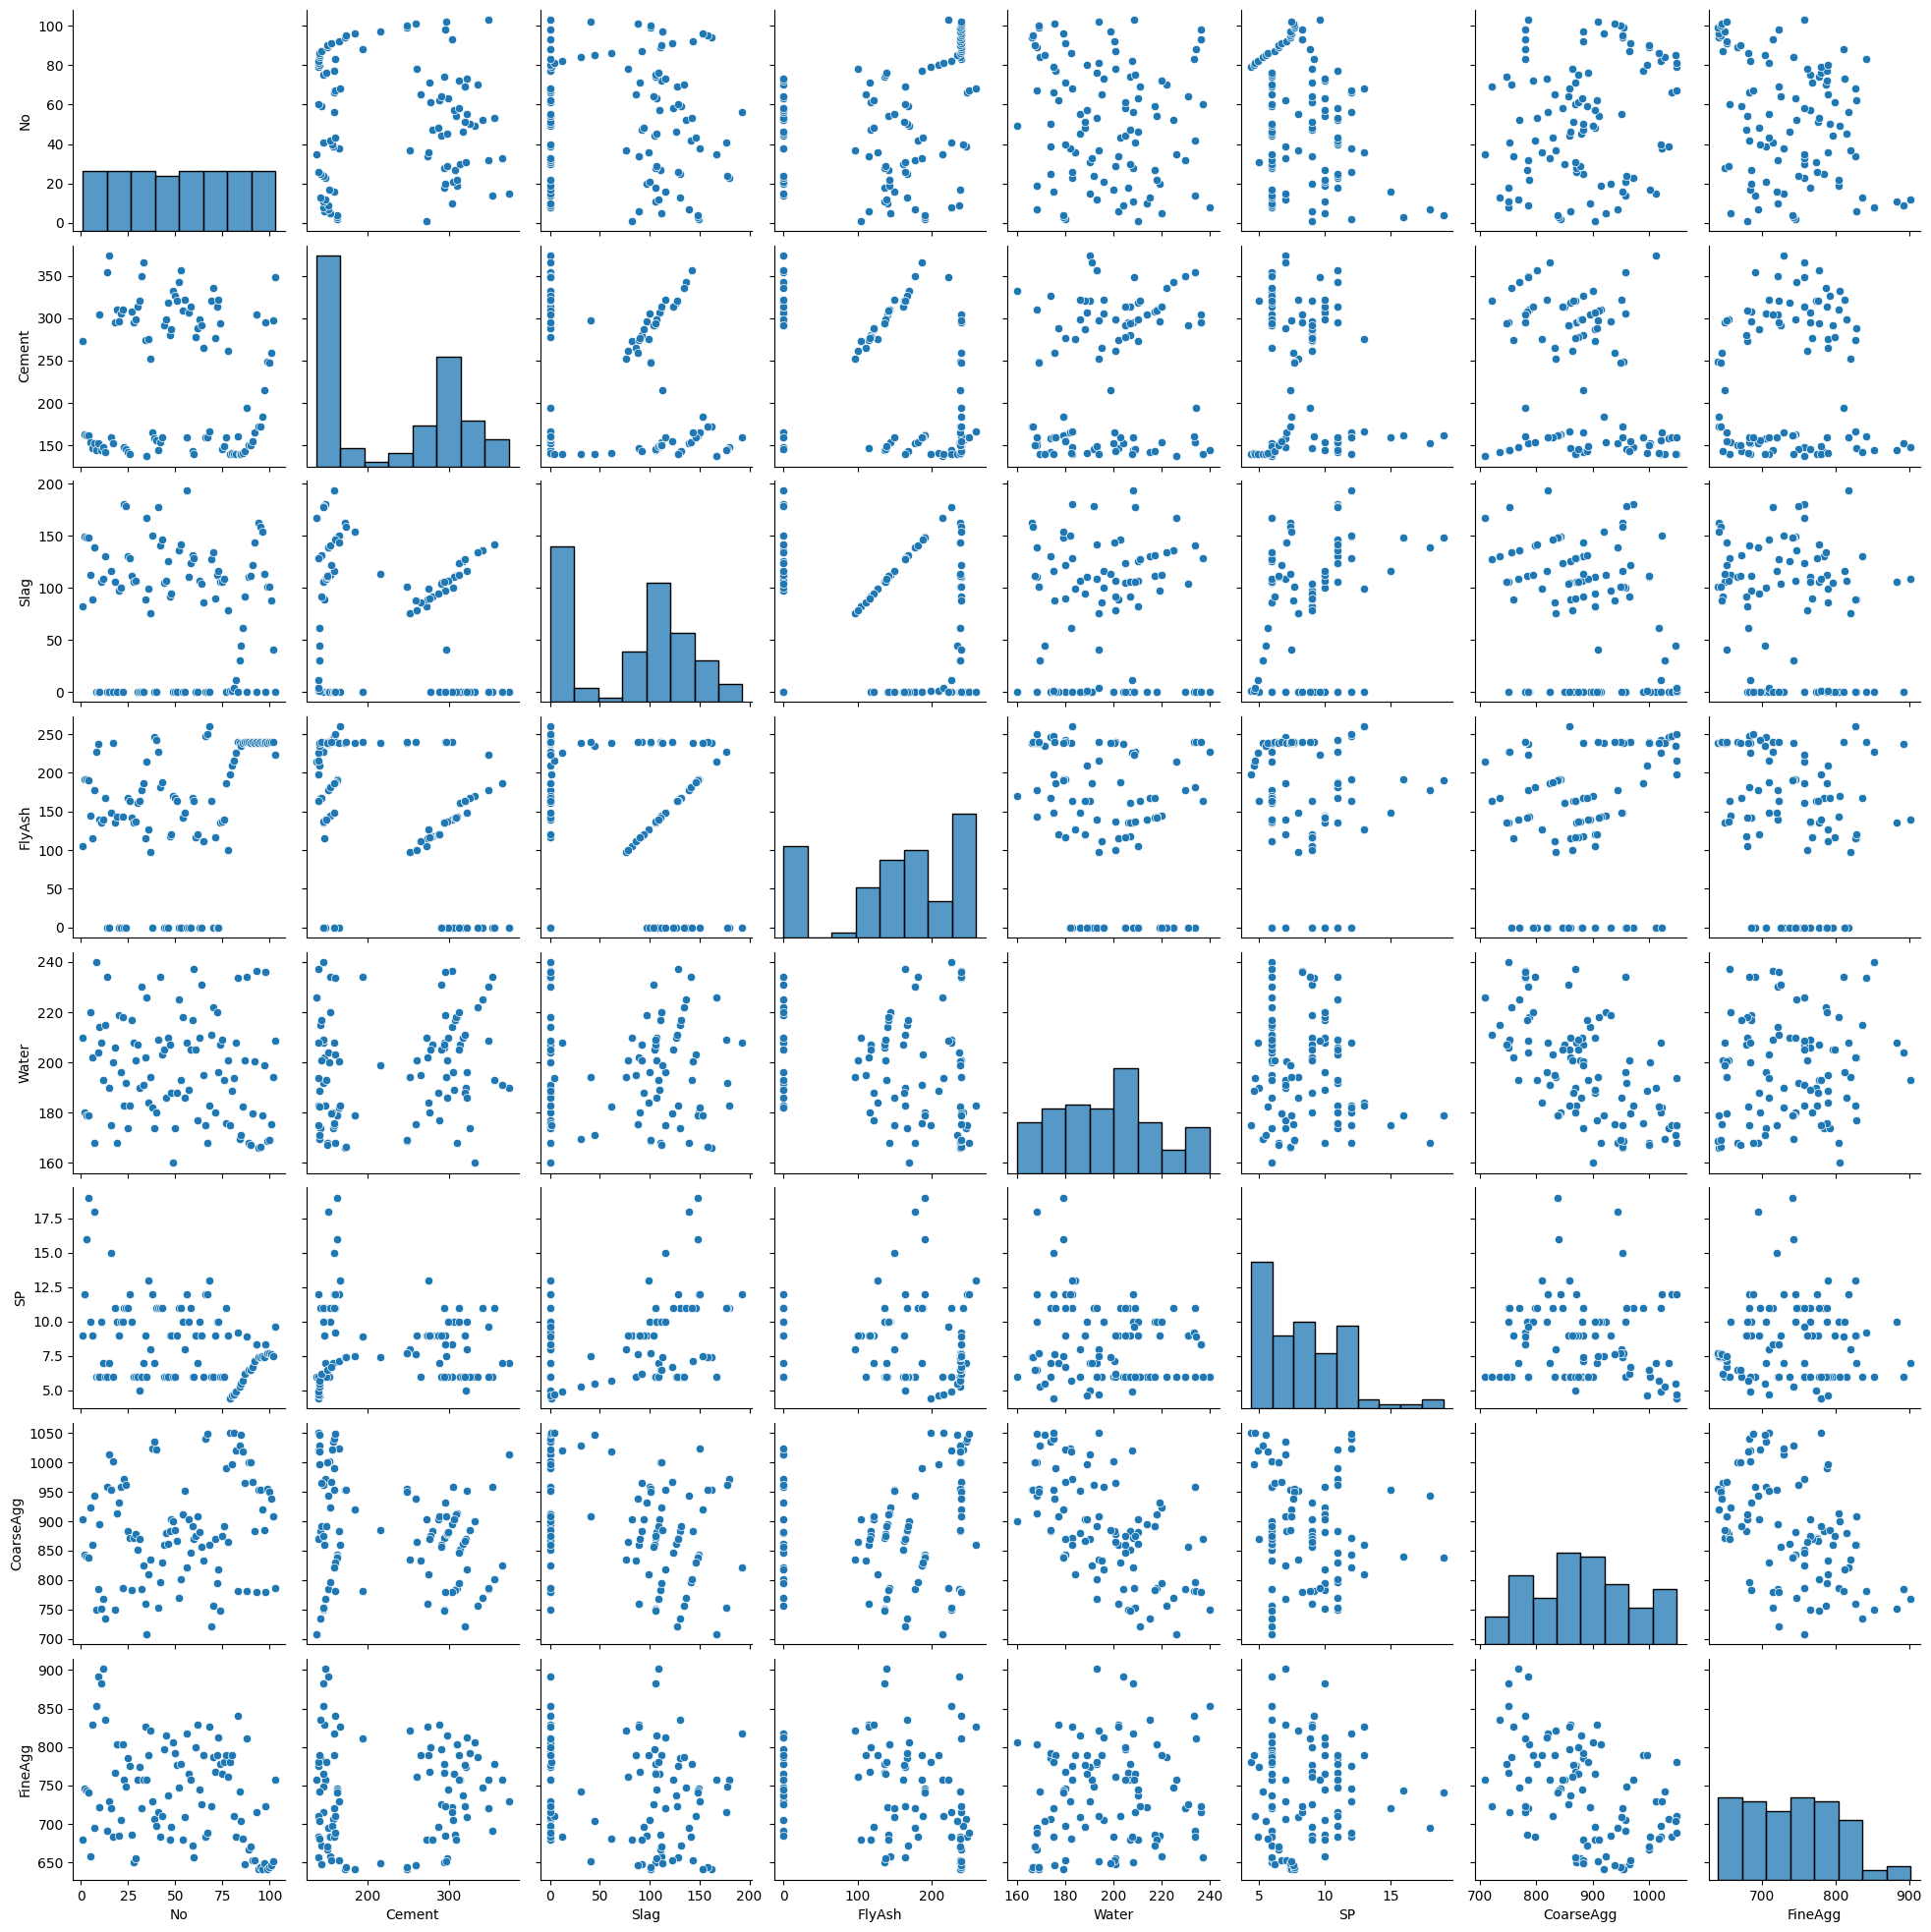

In [14]:
sns.pairplot(X[['No',
 'Cement',
 'Slag',
 'FlyAsh',
 'Water',
 'SP',
 'CoarseAgg',
 'FineAgg']]);

## Correlation matrix¶
If the scatterplot matrix remains too hard to read, you can always revert to a simple correlation matrix.

In [15]:
round(con.corr(),2)

,No,Cement,Slag,FlyAsh,Water,SP,CoarseAgg,FineAgg,Strength
No,1.00,-0.03,-0.08,0.34,-0.14,-0.33,0.22,-0.31,0.19
Cement,-0.03,1.00,-0.24,-0.49,0.22,-0.11,-0.31,0.06,0.46
Slag,-0.08,-0.24,1.00,-0.32,-0.03,0.31,-0.22,-0.18,-0.33
FlyAsh,0.34,-0.49,-0.32,1.00,-0.24,-0.14,0.17,-0.28,0.41
Water,-0.14,0.22,-0.03,-0.24,1.00,-0.16,-0.60,0.11,-0.22
SP,-0.33,-0.11,0.31,-0.14,-0.16,1.00,-0.10,0.06,-0.02
CoarseAgg,0.22,-0.31,-0.22,0.17,-0.60,-0.10,1.00,-0.49,-0.15
FineAgg,-0.31,0.06,-0.18,-0.28,0.11,0.06,-0.49,1.00,-0.17
Strength,0.19,0.46,-0.33,0.41,-0.22,-0.02,-0.15,-0.17,1.00


## Model refinement

The kitchen sink model is unlikely to be the best model. At the very least, we need to remove variables that should not be in the model for methodological reasons, such as collinearity. Then, depending on our philosophical view on such things, we can go into data mining mode and attempt to generate the “best” model by removing or adding explanatory variables. Two clarifications:

The best model is typically defined in terms of the trade-off between goodness of fit (e.g., 
) and model complexity (the number of explanatory variables). This trade-off provides the rationale for the adjusted 
 measure. Given two models with similar explanatory power, the one with the fewest explanatory variables is deemed better.

Data mining mode means we suspend our knowledge about the underlying domain and instead focus on technical measures of explanatory power. In this mode, we keep our theories about cause and effect to ourselves: If the measure indicates a variable has explanatory power, we leave it in the model; if the measure indicates the variable has low explanatory power, we take it out of the model

## Manual stepwise refinement
When we did manual stepwise refinement in Excel, our heuristic was to start with the kitchen sink model and remove the variable with the highest p-value (probability of zero slope).

If we scroll up to the results of the kitchen sink model, we see that the variable with the highest p-value is “FineAgg”. If we are using the matrix version of the OLS() method, we can drop the column from the X matrix.

In [17]:
X1 = X.drop(columns='FineAgg', inplace=False)
mod1 = sm.OLS(Y, X1)
mod1_res = mod1.fit()
mod1_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               Strength   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     64.60
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           2.43e-33
Time:                        12:51:30   Log-Likelihood:                -284.70
No. Observations:                 103   AIC:                             585.4
Df Residuals:                      95   BIC:                             606.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.8748     12.948      2.076      0.041       1.170      52.580
No            -0.0159      0.016     -0.994      0.323      -0.048       0.016
Cement         0.1114      0.008     14.080      0.000       0.096       0.127
Slag           0.0175      0.010      1.833      0.070      -0.001       0.037
FlyAsh         0.0966      0.008     12.738      0.000       0.082       0.112
Water         -0.1296      0.028     -4.633      0.000      -0.185      -0.074
SP             0.3375      0.162      2.080      0.040       0.015       0.660
CoarseAgg     -0.0135      0.007     -1.892      0.062      -0.028       0.001
==============================================================================
Omnibus:                        2.187   Durbin-Watson:                   1.713
Prob(Omnibus):                  0.335   Jarque-Bera (JB):                2.177
Skew:                          -0.300   Prob(JB):                        0.337
Kurtosis:                       2.615   Cond. No.                     3.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Automated stepwise refinement¶

Unfortunately for us, model refinement is conspicuously absent from the popular Python libraries. My own theory is this:

Hardcore statisticians do not believe in iterative model refinement. Instead, they believe model selection should be guided by a solid understanding of the underlying domain. In this view, a variable should only be included in a model if there is a reason to include it (if a plausible story can be told about why it should be in the model).

The machine learning community is understandably more sympathetic to the “throw everything into the model and let the algorithm sort it out” approach. However, this community has no special affinity for ordinary least squares regression—there are so many other techniques out there that are deemed better/more stable.

The bottom line (in my theory) is that neither the hardcore statistics community nor the machine learning community see iterative refinement of OLS models as worthwhile for real-word modeling. Accordingly, you should adopt one of the two perspectives above:

Use manual model refinement guided by domain knowledge to create a linear regression model that makes sense

Build on your new foundation of Python to learn more sophisticated machine learning techniques and forget about stepwise refinement of linear regression.

Given this, I have moved the section on stepwise refinement to the end of the lesson.


## Regression diagnostics¶
As we did in the lesson on simple regression, we can generate our favorite diagnostic plots to determine whether the resulting regression model is valid.

C:\Users\abuel\AppData\Local\Temp\ipykernel_48720\3361389001.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mod1_res.resid, fit=stats.norm);


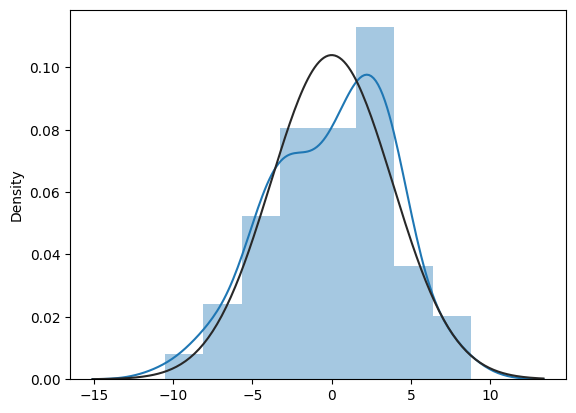

In [20]:
from scipy import stats
sns.distplot(mod1_res.resid, fit=stats.norm);

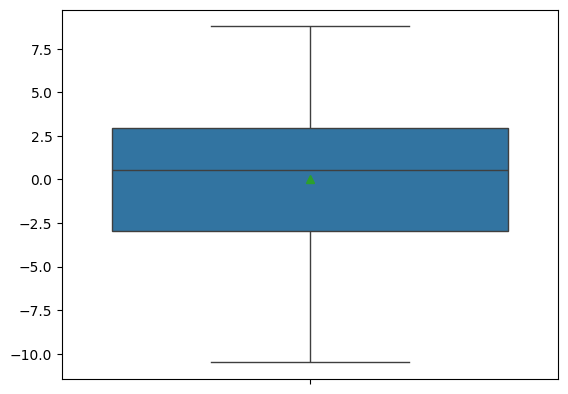

In [21]:
sns.boxplot(mod1_res.resid, showmeans=True);

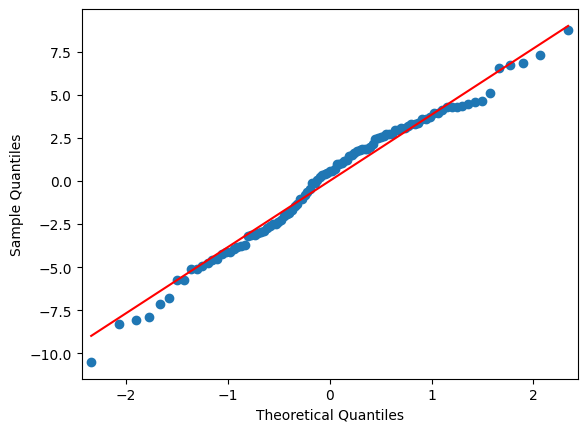

In [22]:
sm.qqplot(mod1_res.resid, line='s');

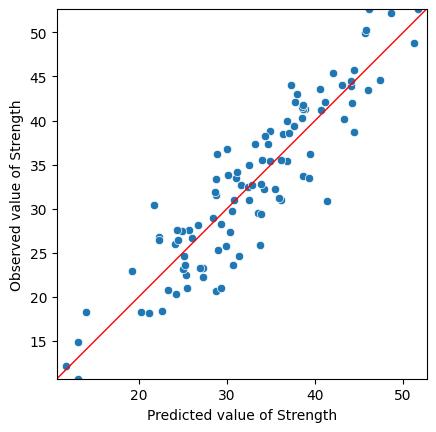

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Make sure these are 1D arrays
y = np.asarray(Y).ravel()
yhat = np.asarray(mod1_res.fittedvalues).ravel()

# Use a shared min/max so the 45-degree line and limits match
mn = min(y.min(), yhat.min())
mx = max(y.max(), yhat.max())

ax = sns.scatterplot(x=yhat, y=y)
ax.set(xlim=(mn, mx), ylim=(mn, mx))
ax.set_xlabel("Predicted value of Strength")
ax.set_ylabel("Observed value of Strength")

# 45-degree reference line
ax.plot([mn, mx], [mn, mx], color="red", linewidth=1)

# Optional: make the plot square so the line looks like 45 degrees
ax.set_aspect("equal", adjustable="box")

plt.show()